#**Fintrack : Analisis Pola Pengeluaran Mahasiswa**

Setiap Mahasiswa memiliki kondisi finansial dan kebiasaan pengeluaran yang berbeda tergantung kondisi ekonomi, kebutuhan akademik, dan gaya hidup. Beberapa memiliki pengeluaran tinggi pada kebutuhan utama seperti tempat tinggal dan makanan, terdapat juga yang memiliki pengeluaran lebih besar pada hiburan atau teknologi.

1. Bagaimana hubungan antara monthly income dan total spending mahasiswa, apakah peningkatan pemasukan diikuti peningkatan pengeluaran?

2. Kategori pengeluaran apa yang memiliki rata-rata pengeluaran tertinggi pada mahasiswa

3. Bagaimana perbedaan pola pengeluaran mahasiswa berdasarkan metode pembayaran yang digunakan?

4. Bagaimana pengelompokan mahasiswa berdasarkan pola pengeluaran dan kondisi finansial mereka menggunakan metode clustering?

# **Data Wrangling**

##Import Library


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

##Import Dataset

In [ ]:
df = pd.read_excel('/content/Student_Spending_Habit.xlsx')
df.head(10)

,age,gender,year_in_school,major,monthly_income,financial_aid,tuition,housing,food,transportation,books_supplies,entertainment,personal_care,technology,health_wellness,miscellaneous,preferred_payment_method
0,23.0,Female,Freshman,Biology,580.0,771,3789,707,322,170,244,114,75,79,188,107,credit/debit card
1,21.0,Female,Sophomore,NaN,714.0,645,3751,853,149,66,184,35,21,219,176,72,Mobile Payment App
2,-2.0,Female,Senior,Engineering,861.0,776,4227,924,143,190,208,114,82,119,172,71,credit/debit card
3,18.0,Non-binary,Freshman,Economics,1408.0,572,45000,477,320,78,150,150,81,163,46,24,mobile payment app
4,23.0,Male,Sophomore,Psychology,1465.0,302,5417,468,113,190,134,119,82,276,165,191,Mobile Payment App
5,18.0,Non-binary,Sophomore,Engineering,791.0,739,5601,628,269,116,102,55,58,179,66,136,Cash
6,24.0,Male,Senior,Biology,804.0,640,3043,927,347,167,151,114,35,206,94,169,Credit/Debit Card
7,23.0,Female,Junior,Engineering,1049.0,476,5972,663,116,162,52,110,21,202,86,63,Mobile Payment App
8,21.0,Male,Junior,Biology,810.0,73,4884,742,112,173,276,136,63,294,161,136,Mobile Payment App
9,23.0,Non-binary,Freshman,Computer Science,815.0,76,4461,446,132,165,165,58,99,135,174,111,Cash


In [ ]:
df.describe()

,age,monthly_income,financial_aid,tuition,housing,food,transportation,books_supplies,entertainment,personal_care,technology,health_wellness,miscellaneous
count,998.000000,966.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000
mean,22.089178,1138.297196,507.184762,4882.570476,695.828571,253.166667,124.952381,175.260952,84.960952,60.795238,178.014286,114.324762,108.791429
std,7.342670,911.343350,287.493614,4256.845519,170.689420,87.004409,43.354499,72.595242,37.848166,22.995979,71.938320,49.409750,52.419272
min,-2.000000,501.000000,0.000000,-1500.000000,401.000000,100.000000,50.000000,50.000000,20.000000,20.000000,50.000000,30.000000,20.000000
25%,20.000000,779.250000,265.000000,3761.000000,539.250000,175.000000,88.000000,112.000000,54.000000,41.000000,113.000000,73.000000,64.000000
50%,22.000000,1034.000000,516.500000,4543.500000,704.500000,256.000000,124.500000,175.000000,86.000000,62.000000,178.000000,114.500000,109.500000
75%,24.000000,1308.250000,754.750000,5292.000000,836.750000,331.000000,162.000000,238.000000,116.000000,80.000000,241.000000,157.750000,153.000000
max,150.000000,10414.891054,1000.000000,45000.000000,1000.000000,400.000000,200.000000,300.000000,150.000000,100.000000,300.000000,200.000000,200.000000


##Informasi Dataset

In [ ]:
df.info()

print("Missing value:")
print(df.isna().sum())

print("Data duplikat:")
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       998 non-null    float64
 1   gender                    1050 non-null   object 
 2   year_in_school            1050 non-null   object 
 3   major                     1008 non-null   object 
 4   monthly_income            966 non-null    float64
 5   financial_aid             1050 non-null   int64  
 6   tuition                   1050 non-null   int64  
 7   housing                   1050 non-null   int64  
 8   food                      1050 non-null   int64  
 9   transportation            1050 non-null   int64  
 10  books_supplies            1050 non-null   int64  
 11  entertainment             1050 non-null   int64  
 12  personal_care             1050 non-null   int64  
 13  technology                1050 non-null   int64  
 14  health_w

Terdapat beberapa kondisi data yang perlu ditangani
- Terdapat missing value pada beberapa kolom yakni Age (52), major (42), monthly income (84), metode pembayaran (52)
- Penulisan data kategorik tidak konsisten
- Terdapat nilai usia yang tidak logis (mines)
- Terdapat 28 data duplikat

#**Data Cleaning**




##Perbaikan Format

In [ ]:
kolom_teks = ['gender', 'year_in_school', 'major', 'preferred_payment_method']
for col in kolom_teks:
    df[col] = df[col].astype(str).str.lower().str.strip()

df.loc[df['age'] < 15, 'age'] = np.nan
df['gender'] = df['gender'].replace({
    'f': 'female',
    'm': 'male',
    'nb': 'non-binary'
})

Penulisan data kategorikal diseragamkan menjadi huruf kecil dan spasi berlebih dihapus agar data konsisten, nilai usia yang tidak logis diubah menjadi missing value agar dapat ditangani di tahap imputasi.

##Hapus Duplikat

In [ ]:
df = df.drop_duplicates()
print("Jumlah data setelah hapus duplikat:", len(df))

Jumlah data setelah hapus duplikat: 1016


Terdapat 28 data duplikat yang dihapus sehingga jumlah data menjadi 1016 observasi. Agar menghindari pengulangan informasi yang dapat memengaruhi hasil analisis.

##Split Train-Test


In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (812, 17)
Test shape: (204, 17)


Dataset dibagi menjadi data training dan data testing dengan proporsi 80:20. 812 data digunakan sebagai training dan 204 data sebagai testing. Proses split dilakukan sebelum imputasi, encoding, scaling, dan penanganan outlier untuk hindari data leakage pada proses analisis.

##Handling Missing Value

Visualisasi Missing Value Data Train

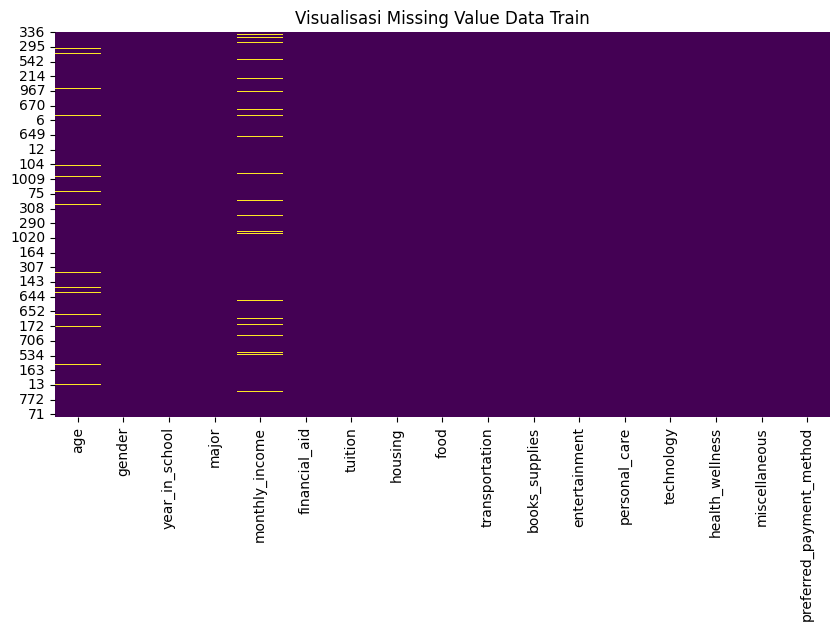

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap( train_df.isnull(),
            cbar=False,
             cmap='viridis' )
plt.title('Visualisasi Missing Value Data Train')
plt.show()

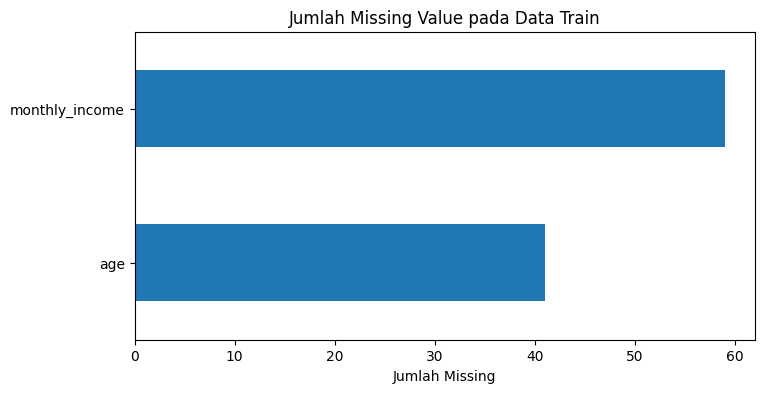

In [ ]:
missing = train_df.isna().sum()
missing = missing[missing > 0]
plt.figure(figsize=(8,4))
missing.sort_values().plot( kind='barh' )
plt.title('Jumlah Missing Value pada Data Train')
plt.xlabel('Jumlah Missing')
plt.show()

Berdasarkan visualisasi missing value, ditemukan bahwa data train masih memiliki nilai kosong pada beberapa variabel, terutama pada monthly_income dan age. Variabel lain tidak menunjukkan missing value yang signifikan sehingga tidak memerlukan penanganan khusus.

- monthly_income memiliki jumlah missing value paling tinggi.
- age juga memiliki missing value dengan jumlah cukup banyak.
- Missing value tersebar secara acak dan tidak membentuk pola tertentu.

Imputasi Missing Value

In [ ]:
# imputasi numerik berdasarkan train
age_median = train_df['age'].median()
income_median = train_df['monthly_income'].median()

train_df['age'] = train_df['age'].fillna(age_median)
test_df['age'] = test_df['age'].fillna(age_median)

train_df['monthly_income'] = train_df[ 'monthly_income' ].fillna(income_median)
test_df['monthly_income'] = test_df[ 'monthly_income' ].fillna(income_median)

# imputasi kategorik
train_df['major'] = train_df[ 'major' ].replace('nan', 'unknown')
test_df['major'] = test_df[ 'major' ].replace('nan', 'unknown')
train_df['preferred_payment_method'] = train_df[ 'preferred_payment_method' ].replace('nan', 'unknown')
test_df['preferred_payment_method'] = test_df[ 'preferred_payment_method' ].replace('nan', 'unknown')

print("Missing value train:")
print(train_df.isna().sum())
print("\nMissing value test:")
print(test_df.isna().sum())

Missing value train:
age                         0
gender                      0
year_in_school              0
major                       0
monthly_income              0
financial_aid               0
tuition                     0
housing                     0
food                        0
transportation              0
books_supplies              0
entertainment               0
personal_care               0
technology                  0
health_wellness             0
miscellaneous               0
preferred_payment_method    0
dtype: int64

Missing value test:
age                         0
gender                      0
year_in_school              0
major                       0
monthly_income              0
financial_aid               0
tuition                     0
housing                     0
food                        0
transportation              0
books_supplies              0
entertainment               0
personal_care               0
technology                  0
health_wellness

Variabel yang missing value merupakan data numerik, maka ditangani menggunakan metode imputasi agar data tetap dapat digunakan dalam proses analisis dan pemodelan tanpa mengurangi jumlah data.

- age diisi menggunakan nilai median karena lebih robust terhadap outlier.
- monthly_income diisi menggunakan nilai median untuk menjaga distribusi data tetap stabil.

Imputasi dilakukan dengan menggunakan parameter dari data train, kemudian diterapkan pada data test. Setelah proses imputasi, dataset tidak memiliki missing value dan siap digunakan pada tahap preprocessing maupun modeling selanjutnya.


## Handling Outliers

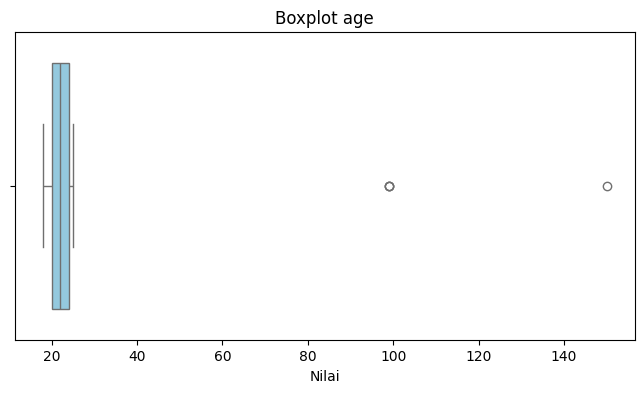

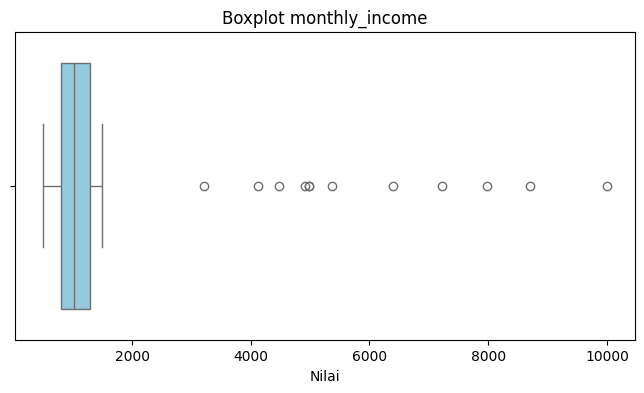

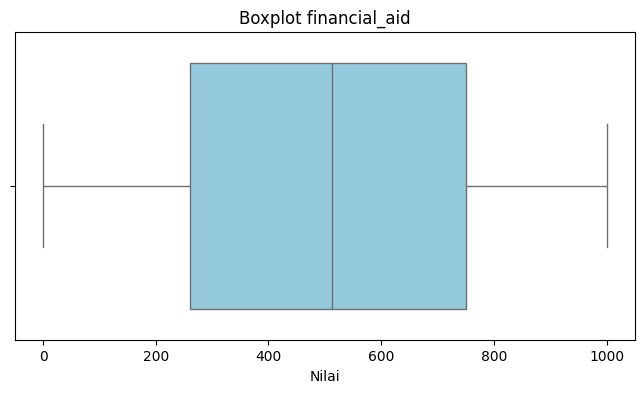

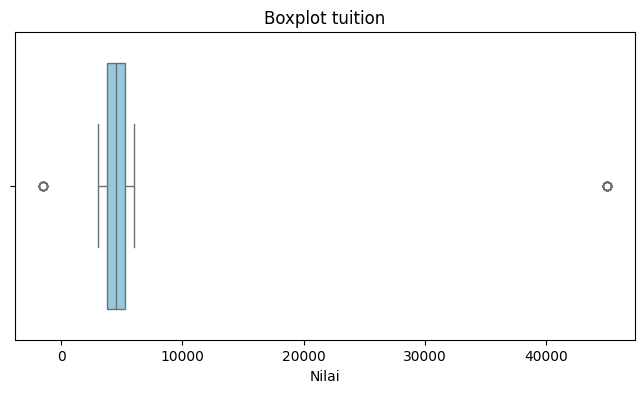

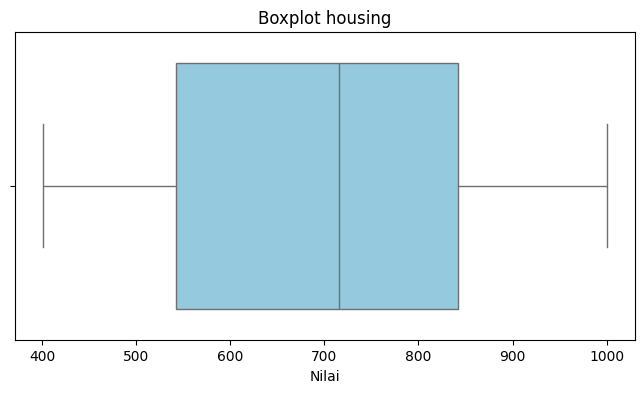

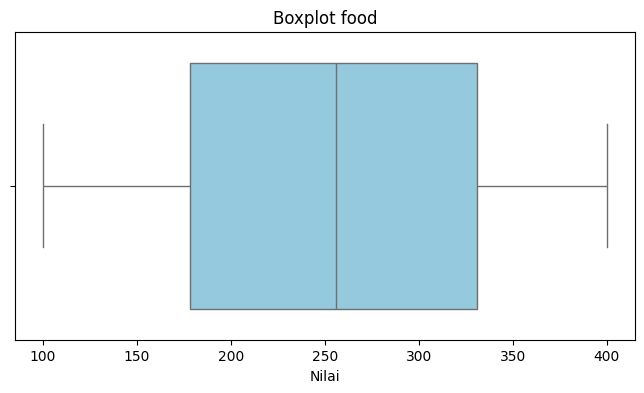

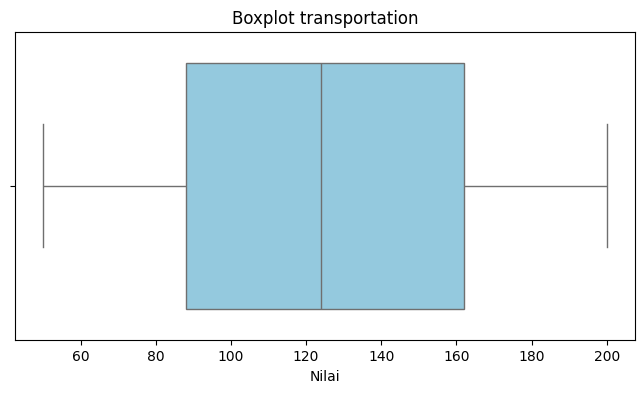

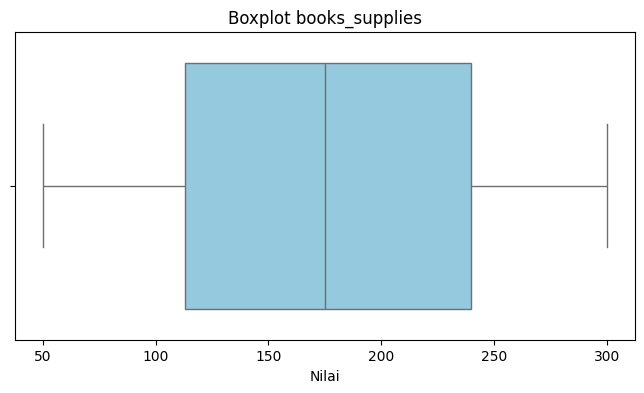

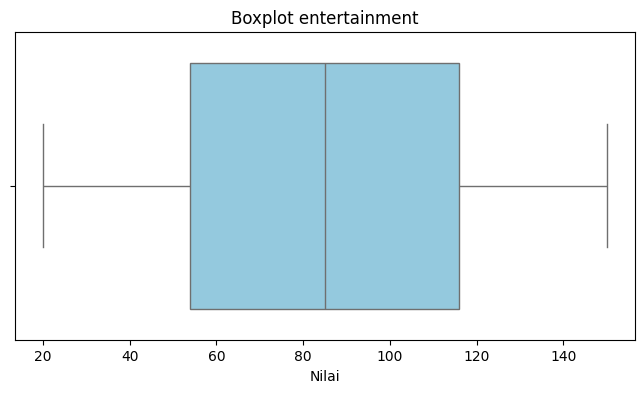

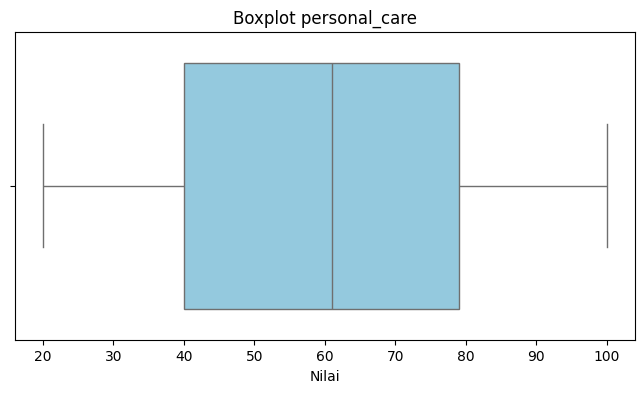

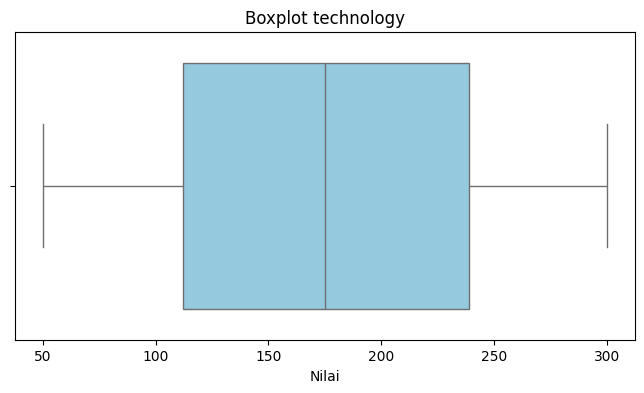

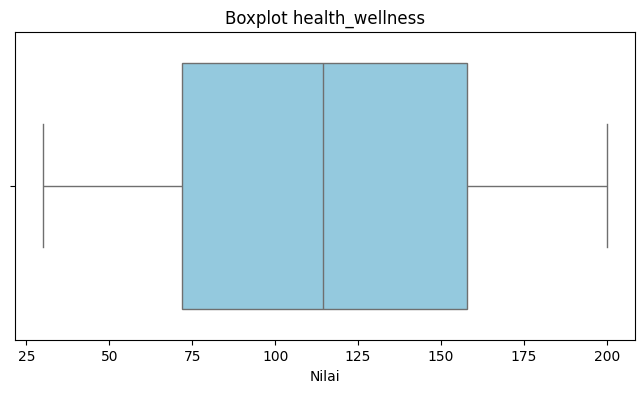

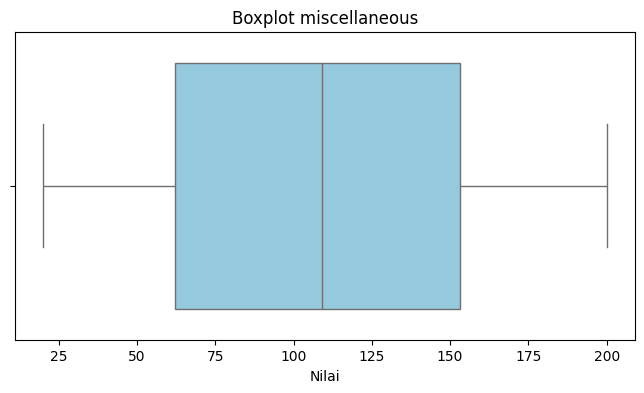

In [ ]:
kolom_numerik = train_df.select_dtypes( include=['number'] ).columns
for col in kolom_numerik:
  plt.figure(figsize=(8,4))
  sns.boxplot( x=train_df[col], color='skyblue' )
  plt.title(f'Boxplot {col}')
  plt.xlabel('Nilai')
  plt.show()

Terdapat outlier pada beberapa variabel numerik, perlu penanganan agar distribusi stabil

In [ ]:
def remove_outliers_iqr_train(train_data, test_data, column):
    Q1 = train_data[column].quantile(0.25)
    Q3 = train_data[column].quantile(0.75)

    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    train_filtered = train_data[
        (train_data[column] >= lower_bound) &
        (train_data[column] <= upper_bound)
    ]

    test_filtered = test_data[
        (test_data[column] >= lower_bound) &
        (test_data[column] <= upper_bound)
    ]

    return train_filtered, test_filtered


train_df, test_df = remove_outliers_iqr_train(train_df, test_df, 'monthly_income')
train_df, test_df = remove_outliers_iqr_train(train_df, test_df, 'tuition')
train_df, test_df = remove_outliers_iqr_train(train_df, test_df, 'age')

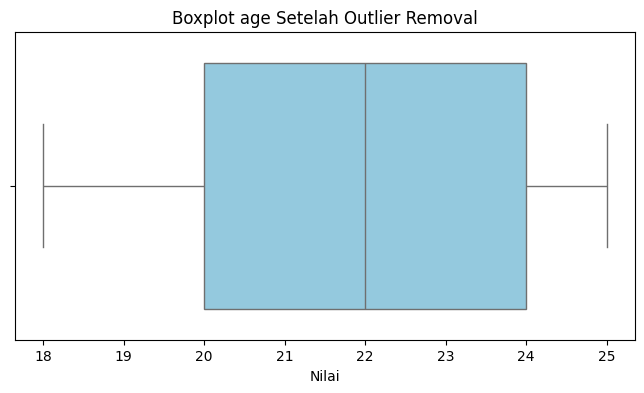

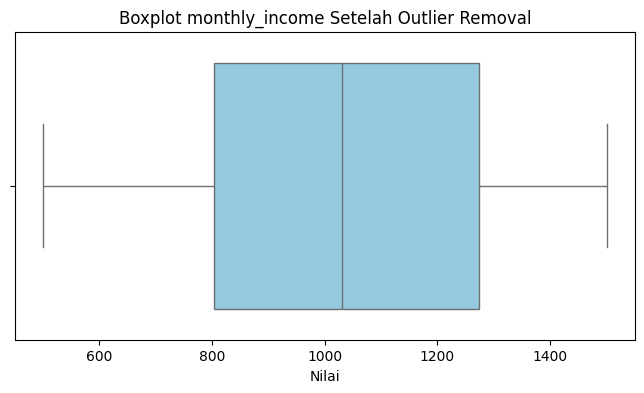

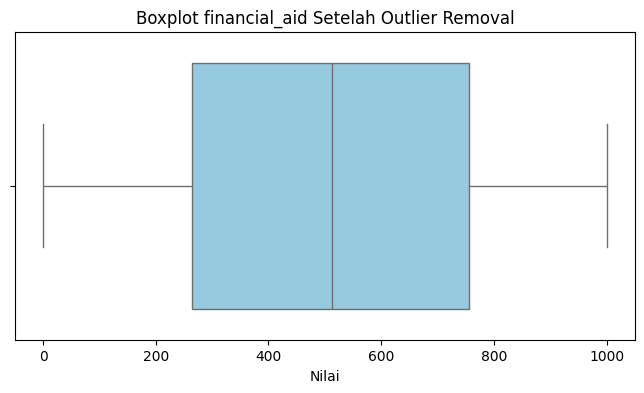

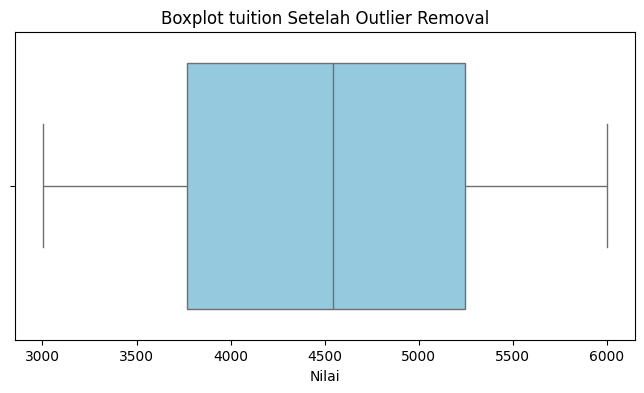

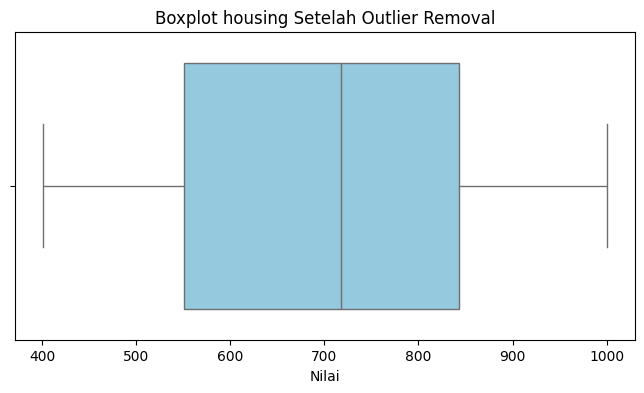

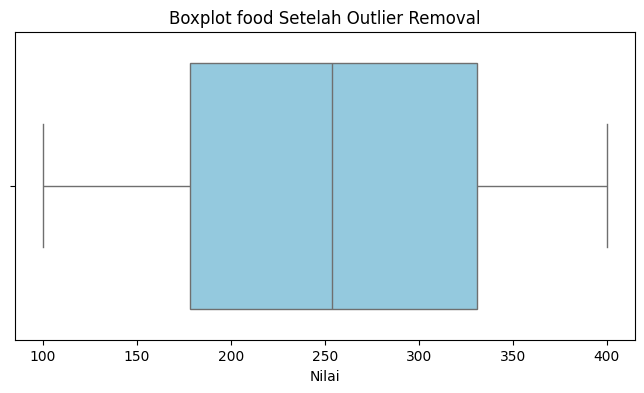

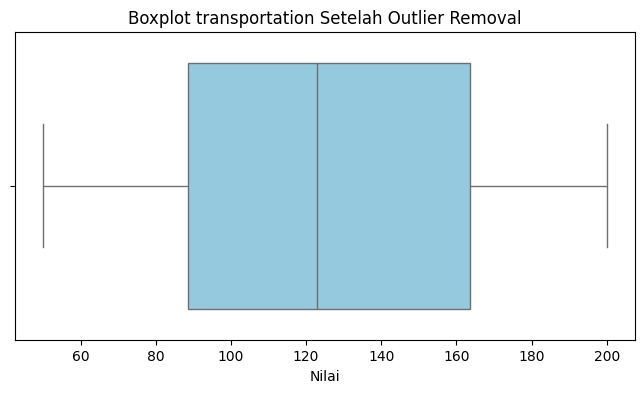

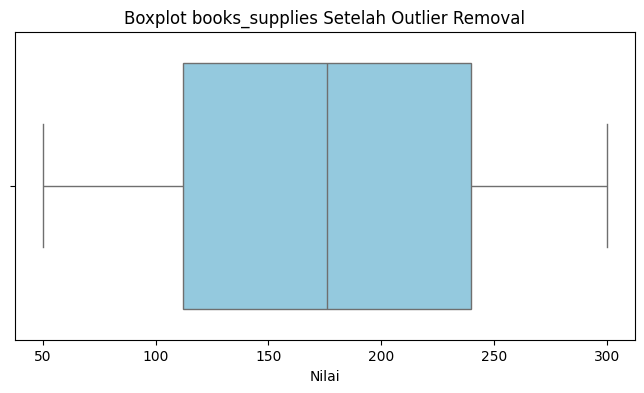

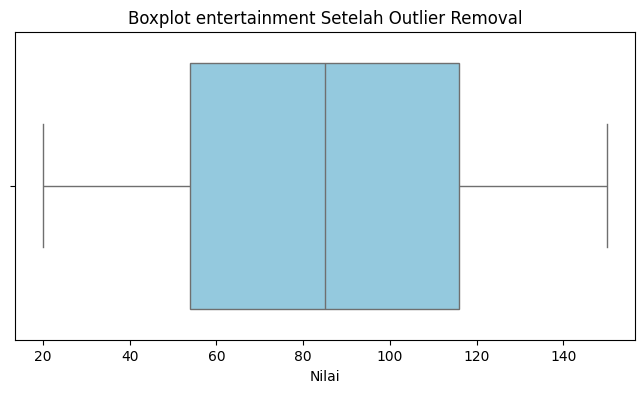

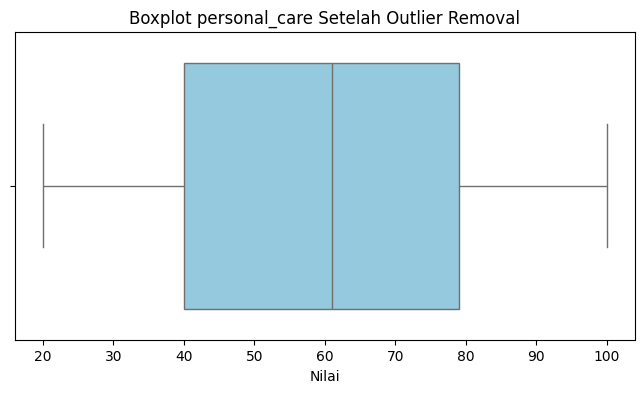

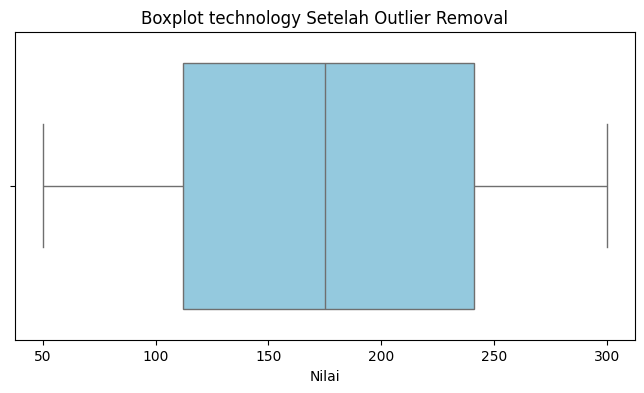

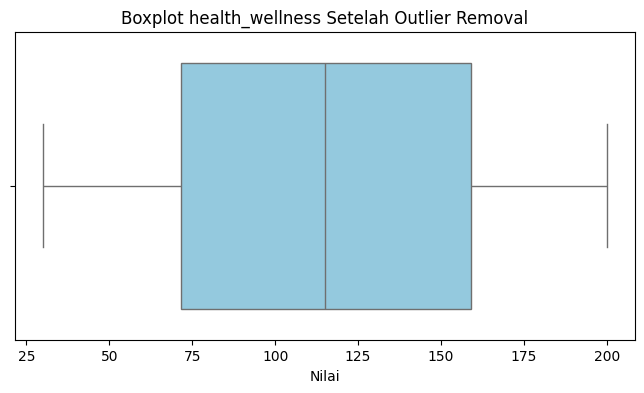

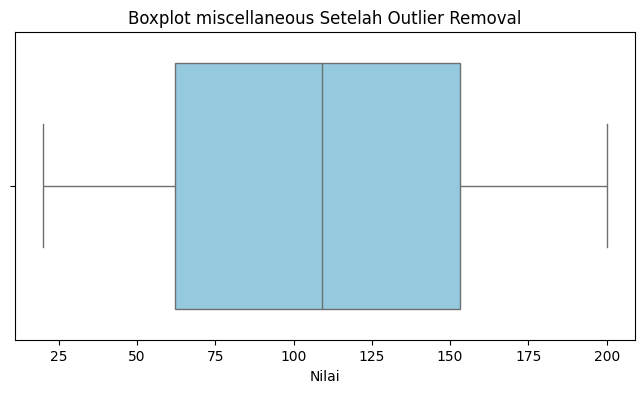

In [ ]:
kolom_numerik = train_df.select_dtypes( include=['number'] ).columns
for col in kolom_numerik:
  plt.figure(figsize=(8,4))
  sns.boxplot( x=train_df[col], color='skyblue' )
  plt.title(f'Boxplot {col} Setelah Outlier Removal')
  plt.xlabel('Nilai')
  plt.show()

Berdasarkan visualisasi boxplot, ditemukan beberapa outlier pada variabel numerik seperti monthly_income, tuition, dan age. Oleh karena itu, dilakukan penanganan outlier menggunakan metode IQR untuk mengurangi pengaruh nilai ekstrem pada data.

Setelah proses outlier removal dilakukan, boxplot menunjukkan bahwa data sudah tidak memiliki outlier yang signifikan sehingga distribusi data menjadi lebih stabil untuk tahap modeling.

In [ ]:
train_df.describe()

,age,monthly_income,financial_aid,tuition,housing,food,transportation,books_supplies,entertainment,personal_care,technology,health_wellness,miscellaneous
count,779.000000,779.000000,779.000000,779.000000,779.000000,779.00000,779.000000,779.000000,779.000000,779.000000,779.000000,779.000000,779.000000
mean,21.748395,1020.302953,506.267009,4508.471117,702.395379,252.88190,125.111682,176.589217,84.599487,59.698331,177.102696,114.616175,107.752246
std,2.269357,284.894073,287.274003,863.245154,172.293684,86.63788,43.395848,73.311118,38.019935,22.722878,72.474211,50.051981,52.879661
min,18.000000,501.000000,0.000000,3003.000000,401.000000,100.00000,50.000000,50.000000,20.000000,20.000000,50.000000,30.000000,20.000000
25%,20.000000,803.500000,264.000000,3770.500000,551.000000,178.00000,88.500000,112.000000,54.000000,40.000000,112.000000,71.500000,62.000000
50%,22.000000,1030.000000,513.000000,4547.000000,718.000000,254.00000,123.000000,176.000000,85.000000,61.000000,175.000000,115.000000,109.000000
75%,24.000000,1273.500000,756.000000,5248.500000,843.500000,331.00000,163.500000,240.000000,116.000000,79.000000,241.000000,159.000000,153.000000
max,25.000000,1500.000000,1000.000000,6000.000000,1000.000000,400.00000,200.000000,300.000000,150.000000,100.000000,300.000000,200.000000,200.000000


Berdasarkan hasil statistik deskriptif setelah proses cleaning dan preprocessing, diperoleh informasi sebagai berikut:

- Dataset terdiri dari 779 data mahasiswa yang siap digunakan untuk tahap modeling.
- Rata-rata usia mahasiswa adalah 21,7 tahun dengan rentang usia 18–25 tahun.
- Rata-rata pendapatan bulanan mahasiswa sebesar 1020.
- Rata-rata bantuan finansial yang diterima mahasiswa sebesar 506.
- Rata-rata biaya tuition mahasiswa sebesar 4508.
- Pengeluaran terbesar mahasiswa berada pada kategori housing dengan rata-rata sebesar 702.
- Rata-rata pengeluaran food sebesar 252 dan transportation sebesar 125.
- Pengeluaran hiburan mahasiswa relatif lebih rendah dengan rata-rata sebesar 84.
- Secara umum, distribusi data numerik sudah cukup stabil setelah proses cleaning dan outlier removal dilakukan.

#**Feature Engineering**


##Total Spending

In [ ]:
kategori_pengeluaran = [
    'housing',
    'food',
    'transportation',
    'books_supplies',
    'entertainment',
    'personal_care',
    'technology',
    'health_wellness',
    'miscellaneous'
]

train_df['total_spending'] = train_df[
    kategori_pengeluaran
].sum(axis=1)

test_df['total_spending'] = test_df[
    kategori_pengeluaran
].sum(axis=1)
train_df[['total_spending']].describe()

,total_spending
count,779.000000
mean,1800.747112
std,239.235192
min,1055.000000
25%,1629.000000
50%,1795.000000
75%,1979.000000
max,2453.000000


Berdasarkan hasil statistik deskriptif, rata-rata total pengeluaran mahasiswa sebesar 1800. Nilai minimum pengeluaran tercatat sebesar 1055 dan maksimum sebesar 2453.

- Sebagian besar mahasiswa memiliki total pengeluaran pada rentang 1629-1979 berdasarkan nilai kuartil data.
- Variasi pengeluaran antar mahasiswa tergolong cukup beragam.
- Secara umum, pola total pengeluaran mahasiswa berada pada tingkat menengah dan relatif stabil.

##Saving Ratio

In [ ]:
train_df['saving_ratio'] = ( (train_df['monthly_income'] - train_df['total_spending']) / train_df['monthly_income'] )
test_df['saving_ratio'] = ( (test_df['monthly_income'] - test_df['total_spending']) / test_df['monthly_income'] )
train_df[['saving_ratio']].describe()

,saving_ratio
count,779.000000
mean,-0.930759
std,0.676734
min,-3.365314
25%,-1.307215
50%,-0.753709
75%,-0.415612
max,0.202601


Berdasarkan hasil statistik deskriptif, rata-rata saving ratio mahasiswa sebesar -0,93. Nilai minimum tercatat sebesar -3,37 dan nilai maksimum sebesar 0,20.

- Sebagian besar mahasiswa memiliki saving ratio bernilai negatif.
- Hal ini menunjukkan bahwa pengeluaran mahasiswa cenderung lebih besar dibandingkan pendapatan yang dimiliki.
- Rentang nilai kuartil menunjukkan saving ratio mayoritas mahasiswa berada pada kisaran -1,31 hingga -0,42.

##Binning Tingkat Pengeluaran

Menunjukkan distribusi data yang seimbang pada kategori low, medium, dan high. Masing-masing kategori memiliki jumlah data yang hampir sama.
Distribusi yang seimbang menunjukkan bahwa pembagian tingkat pengeluaran telah dilakukan dengan baik sehingga setiap kategori dapat digunakan secara optimal dalam proses analisis maupun modeling.

In [ ]:
train_df['spending_level'] = pd.qcut(
    train_df['total_spending'],
    q=3,
    labels=['low', 'medium', 'high']
)

bins = pd.qcut(
    train_df['total_spending'],
    q=3,
    retbins=True
)[1]

test_df['spending_level'] = pd.cut(
    test_df['total_spending'],
    bins=bins,
    labels=['low', 'medium', 'high'],
    include_lowest=True
)
train_df['spending_level'].value_counts()

,count
spending_level,
low,261
high,260
medium,258


#**Eksploratory Data Analysis (EDA)**

##Visualisasi Utama

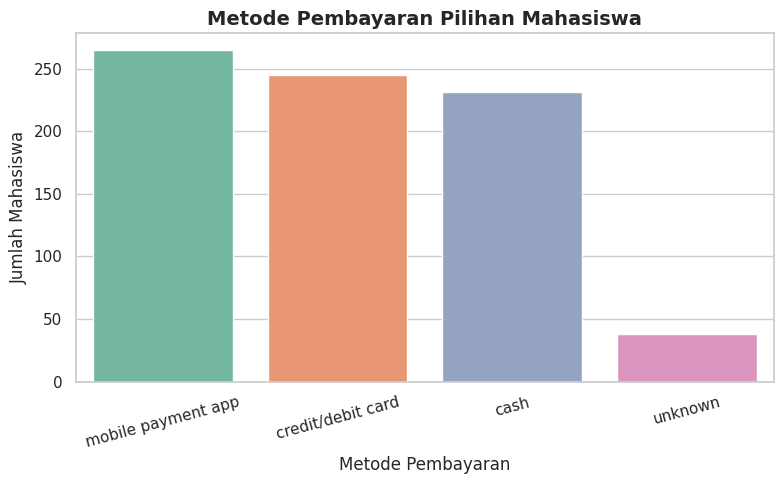

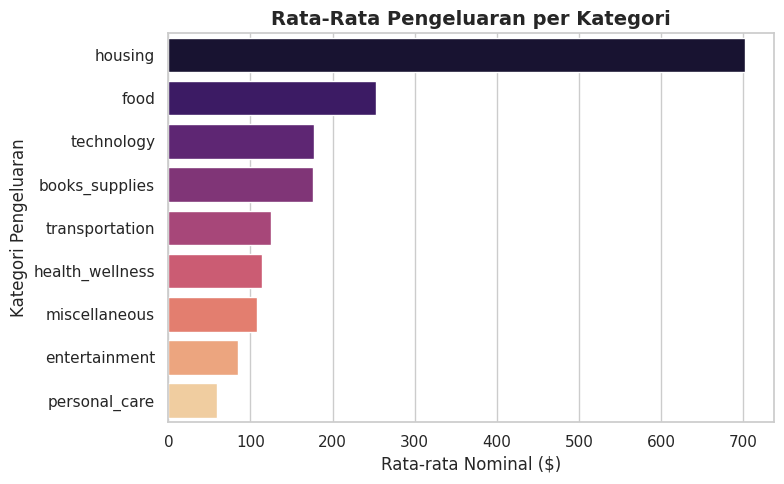

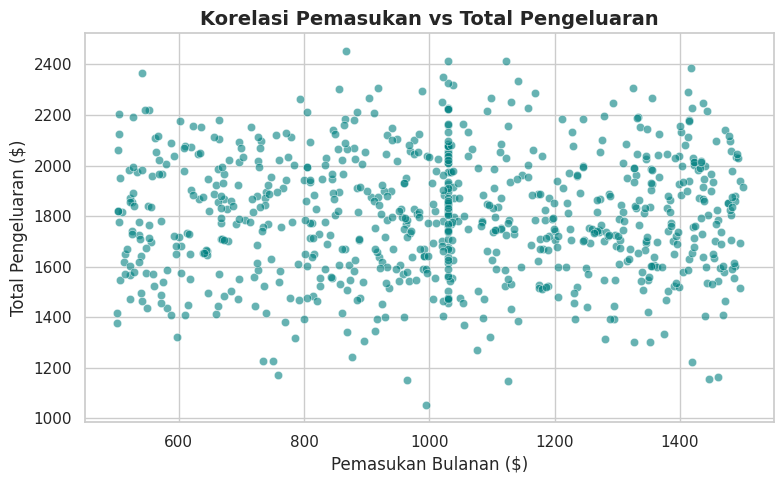

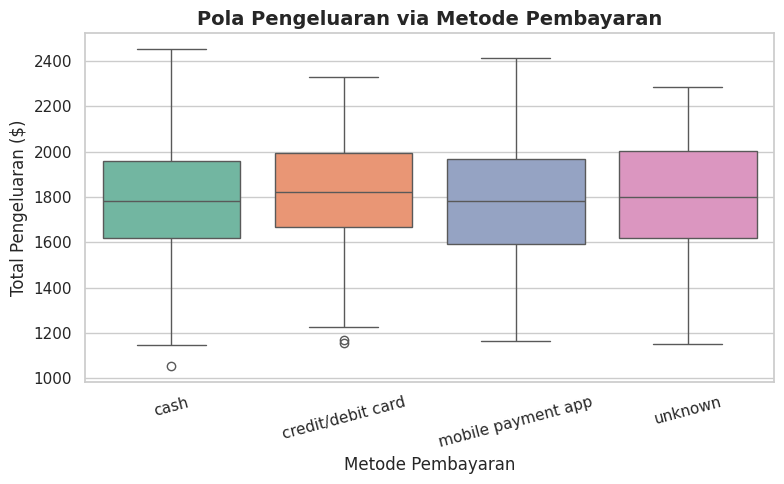

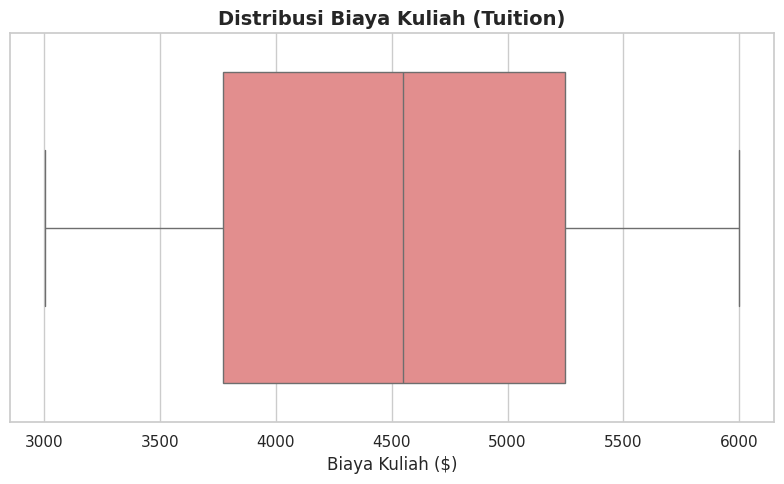

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,5))

#Metode Pembayaran Pilihan Mahasiswa
sns.countplot(
    data=train_df,
    x='preferred_payment_method',
    palette='Set2',
    order=train_df[
        'preferred_payment_method'
    ].value_counts().index)
plt.title(
    'Metode Pembayaran Pilihan Mahasiswa',
    fontsize=14,
    fontweight='bold')
plt.xlabel('Metode Pembayaran')
plt.ylabel('Jumlah Mahasiswa')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#Rata-rata Pengeluaran per Kategori
plt.figure(figsize=(8,5))
rata_pengeluaran = train_df[
    kategori_pengeluaran
].mean().sort_values(ascending=False)
sns.barplot(
    x=rata_pengeluaran.values,
    y=rata_pengeluaran.index,
    palette='magma')
plt.title(
    'Rata-Rata Pengeluaran per Kategori',
    fontsize=14,
    fontweight='bold')
plt.xlabel('Rata-rata Nominal ($)')
plt.ylabel('Kategori Pengeluaran')
plt.tight_layout()
plt.show()

#Pemasukan vs Total Pengeluaran
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=train_df,
    x='monthly_income',
    y='total_spending',
    alpha=0.6,
    color='teal')
plt.title(
    'Korelasi Pemasukan vs Total Pengeluaran',
    fontsize=14,
    fontweight='bold')
plt.xlabel('Pemasukan Bulanan ($)')
plt.ylabel('Total Pengeluaran ($)')
plt.tight_layout()
plt.show()

#Pola Pengeluaran berdasarkan Metode Pembayaran
plt.figure(figsize=(8,5))
sns.boxplot(
    data=train_df,
    x='preferred_payment_method',
    y='total_spending',
    hue='preferred_payment_method',
    palette='Set2',
    legend=False)
plt.title(
    'Pola Pengeluaran via Metode Pembayaran',
    fontsize=14,
    fontweight='bold')
plt.xlabel('Metode Pembayaran')
plt.ylabel('Total Pengeluaran ($)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#Distribusi Biaya Kuliah
plt.figure(figsize=(8,5))
sns.boxplot(
    data=train_df,
    x='tuition',
    color='lightcoral')
plt.title(
    'Distribusi Biaya Kuliah (Tuition)',
    fontsize=14,
    fontweight='bold')
plt.xlabel('Biaya Kuliah ($)')
plt.tight_layout()
plt.show()



- Metode pembayaran yang paling banyak digunakan mahasiswa adalah mobile payment app, diikuti oleh credit/debit card dan cash. Hal ini menunjukkan bahwa sebagian besar mahasiswa sudah terbiasa menggunakan transaksi digital dibanding pembayaran tunai.

- Kategori pengeluaran terbesar mahasiswa berada pada housing, kemudian diikuti oleh food, technology, dan books_supplies. Hal ini menunjukkan bahwa kebutuhan tempat tinggal dan kebutuhan akademik masih menjadi prioritas utama pengeluaran mahasiswa.

- Scatterplot antara monthly_income dan total_spending menunjukkan bahwa tidak terdapat hubungan linear yang terlalu kuat antara pemasukan dan total pengeluaran. Mahasiswa dengan pemasukan tinggi tidak selalu memiliki pengeluaran yang lebih besar karena pola pengeluaran tiap mahasiswa cukup beragam. Sebaran titik pada scatterplot terlihat cukup menyebar pada seluruh rentang pemasukan. Hal ini menunjukkan adanya variasi perilaku finansial mahasiswa dalam mengelola pendapatan dan pengeluaran mereka.

- Boxplot pola pengeluaran berdasarkan metode pembayaran menunjukkan bahwa seluruh metode pembayaran memiliki median pengeluaran yang relatif mirip. Namun, pengguna credit/debit card dan mobile payment app cenderung memiliki variasi pengeluaran yang sedikit lebih besar dibanding pengguna cash.

- Visualisasi distribusi tuition menunjukkan bahwa biaya kuliah mahasiswa berada pada rentang sekitar 3000 hingga 6000 dengan median berada di sekitar 4500. Sebaran data terlihat cukup stabil tanpa adanya outlier yang signifikan setelah proses preprocessing dilakukan.

##Distribusi Variabel Numerik

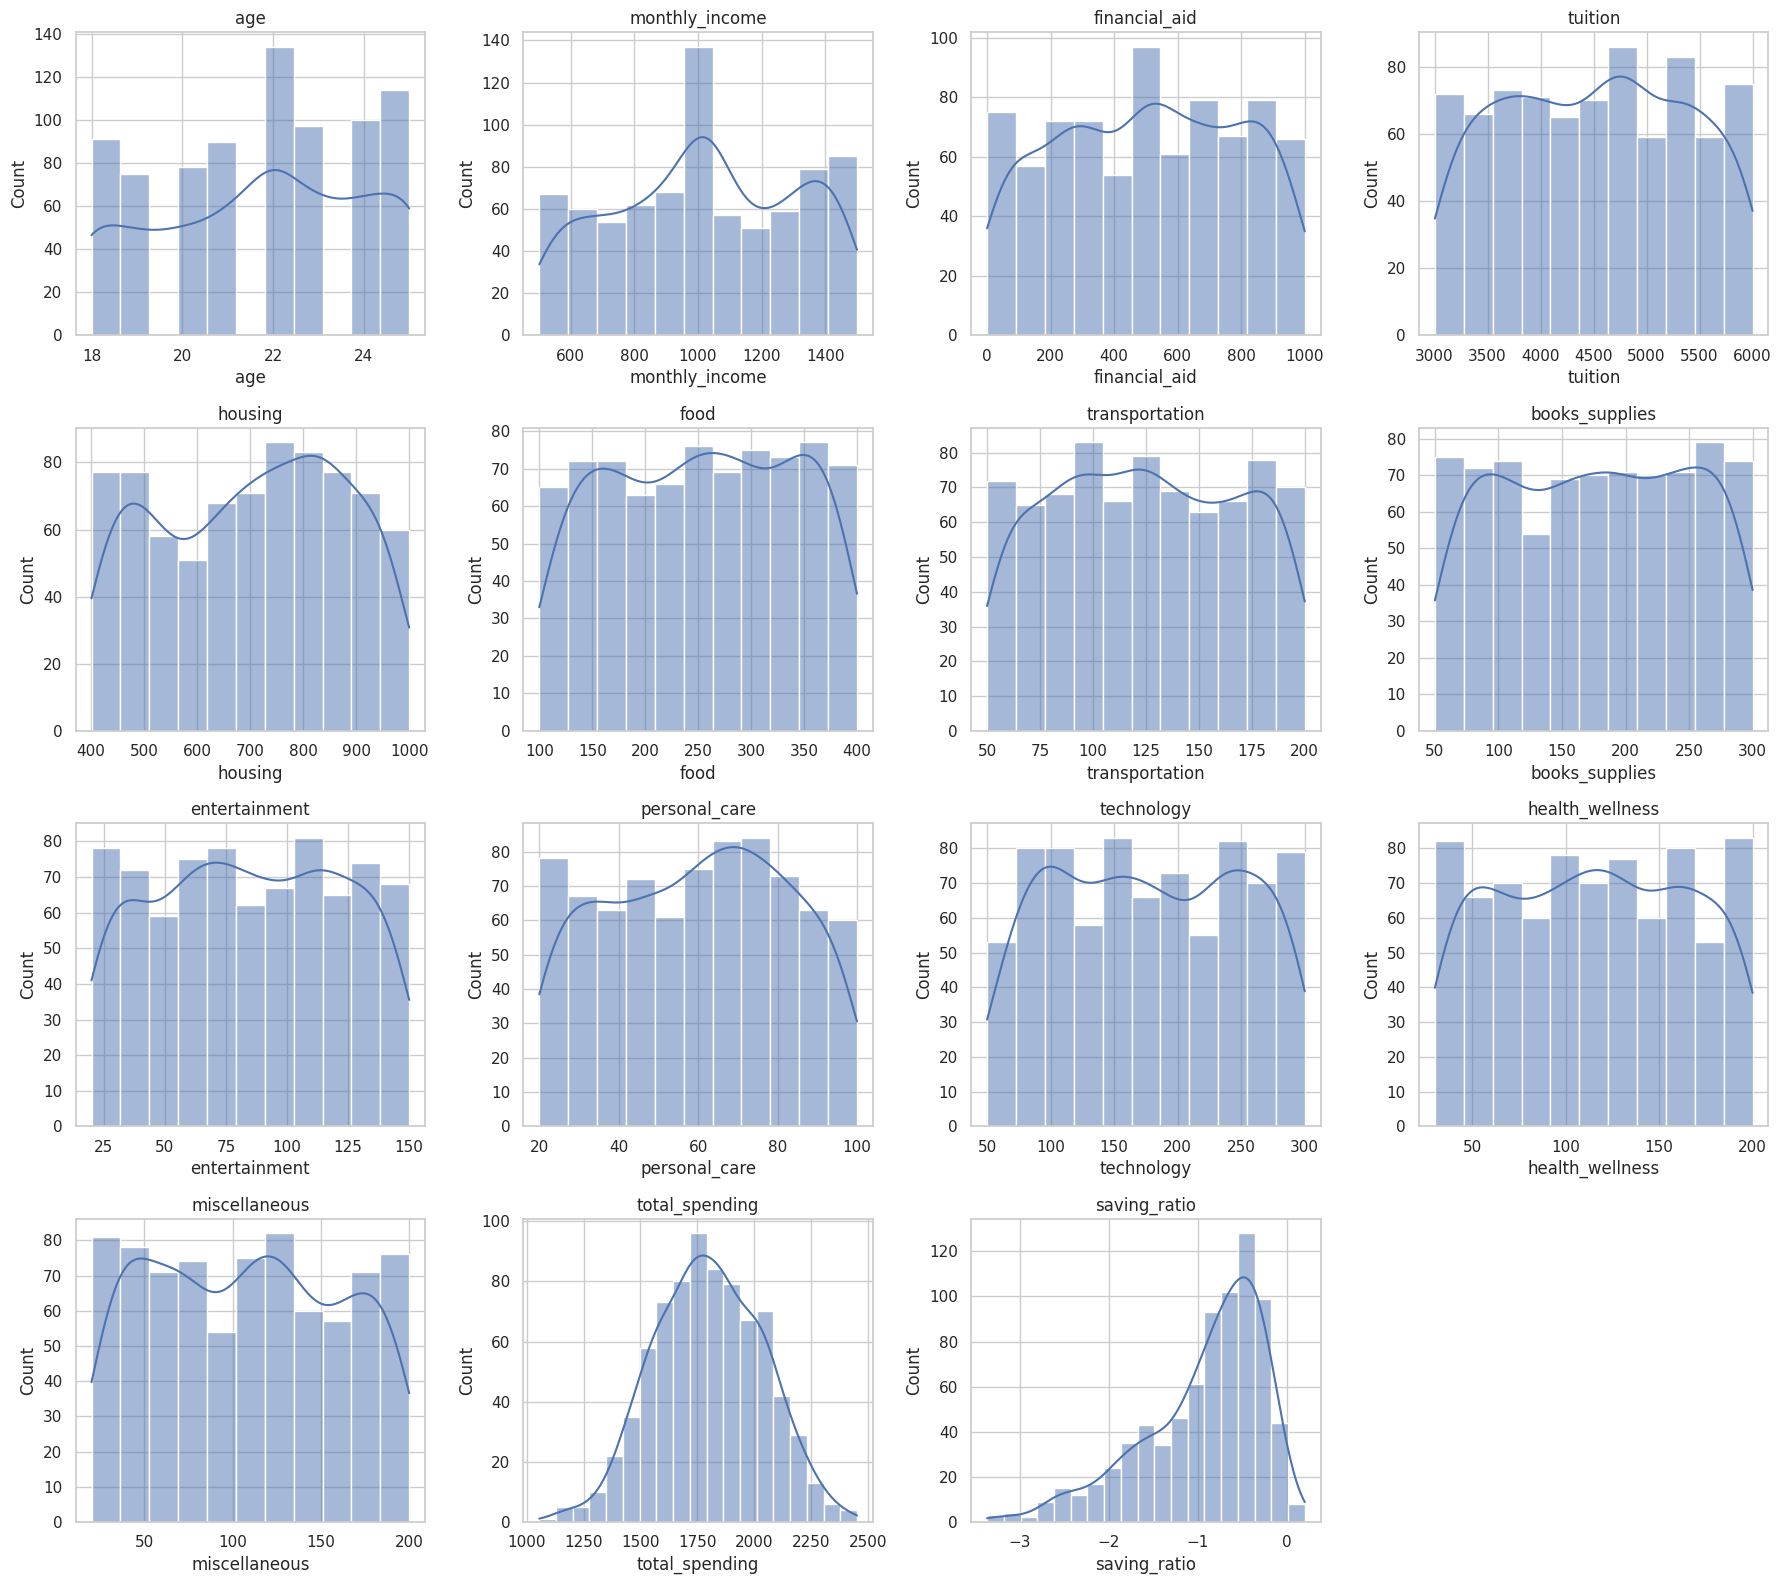

In [ ]:
numerical_cols = train_df.select_dtypes(
    include=['number']).columns
jumlah_kolom = len(numerical_cols)
rows = (jumlah_kolom // 4) + 1
fig, axes = plt.subplots(
    rows,
    4,
    figsize=(18, rows * 4))

axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.histplot(
        train_df[col],
        kde=True,
        ax=axes[i])
    axes[i].set_title(col)

# hapus subplot kosong
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

Sebagian besar variabel numerik menunjukkan distribusi yang cukup merata setelah proses cleaning dan outlier removal dilakukan.

- Variabel monthly_income memiliki distribusi yang terpusat pada rentang menengah, yaitu sekitar 800-1400, sehingga menunjukkan mayoritas mahasiswa memiliki pemasukan bulanan yang relatif stabil.

- Variabel pengeluaran seperti housing, food, technology, dan books_supplies juga memiliki distribusi yang cukup seimbang tanpa adanya lonjakan ekstrem yang signifikan.

- Variabel total_spending menunjukkan distribusi yang mendekati normal dengan puncak data berada pada rentang pengeluaran menengah. Hal ini menunjukkan sebagian besar mahasiswa memiliki pola total pengeluaran yang relatif serupa.

- Variabel saving_ratio didominasi oleh nilai negatif. Hal ini menunjukkan bahwa sebagian besar mahasiswa memiliki total pengeluaran yang lebih besar dibandingkan pemasukan bulanannya.

- Secara umum, distribusi variabel numerik sudah cukup stabil dan layak digunakan untuk tahap analisis maupun modeling.

##Analisis Korelasi

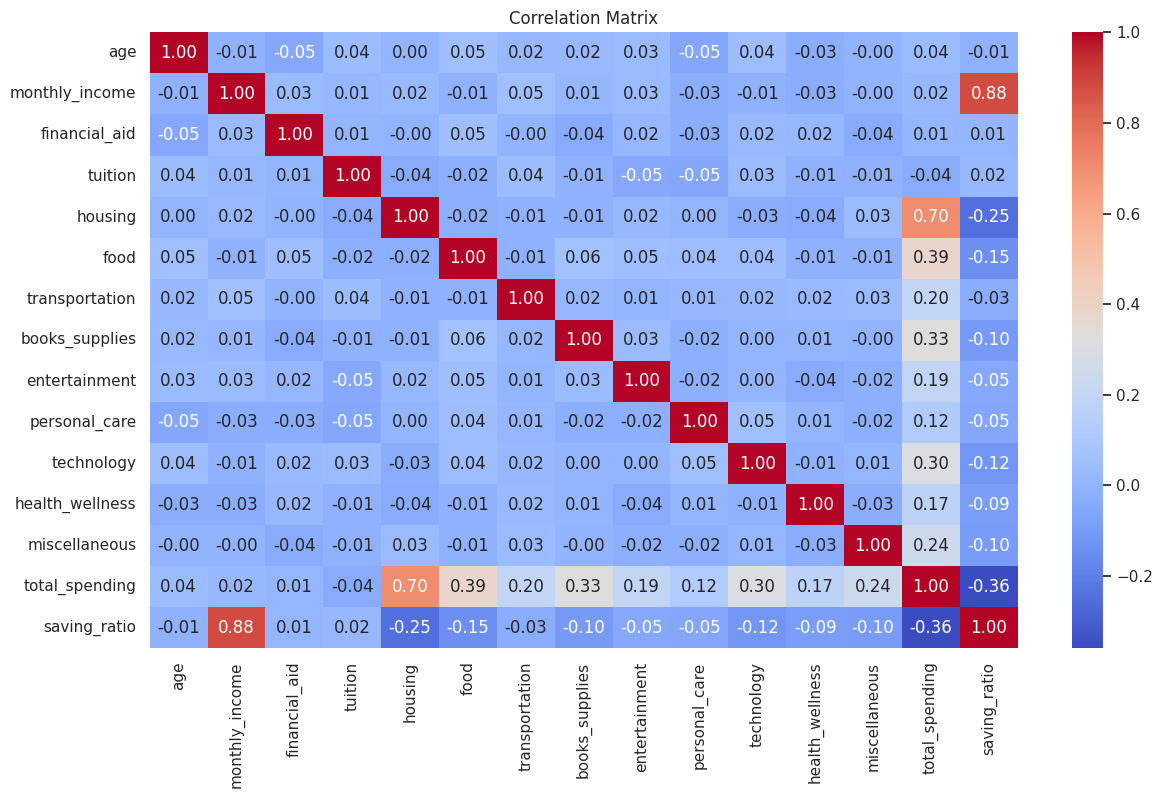

In [ ]:
#Analisis korelasi u/ hubungan antar variabel numerik
plt.figure(figsize=(14,8))
corr = train_df.corr( numeric_only=True )
sns.heatmap( corr, annot=True, cmap='coolwarm', fmt='.2f' )
plt.title('Correlation Matrix')
plt.show()


- Monthly_income memiliki korelasi positif sangat kuat dengan saving_ratio sebesar 0.88. Hal ini menunjukkan bahwa semakin tinggi pemasukan mahasiswa, maka kemampuan menyisihkan uang juga cenderung meningkat.

- Housing memiliki korelasi positif paling kuat terhadap total_spending sebesar 0.70. Hal ini menunjukkan bahwa biaya tempat tinggal menjadi komponen utama dalam total pengeluaran mahasiswa.

- Food, books_supplies, dan technology juga memiliki korelasi positif terhadap total_spending masing-masing sebesar 0.39, 0.33, dan 0.30. Kategori tersebut turut berkontribusi terhadap peningkatan total pengeluaran mahasiswa.

- Saving_ratio memiliki korelasi negatif terhadap total_spending sebesar -0.36. Hal ini menunjukkan bahwa semakin besar pengeluaran mahasiswa, maka kemampuan menyimpan sisa pemasukan cenderung menurun.

- Variabel transportation, entertainment, health_wellness, dan miscellaneous memiliki korelasi positif yang relatif lemah terhadap total_spending, sehingga pengaruhnya tidak sebesar kebutuhan utama seperti housing dan food.

- Variabel age, financial_aid, dan tuition menunjukkan korelasi yang rendah terhadap sebagian besar variabel lain, sehingga pengaruhnya terhadap pola pengeluaran mahasiswa cenderung kecil pada dataset ini.

#**Clustering**
Mengelompokkan mahasiswa berdasarkan karakteristik pengeluaran dan kondisi finansialnya.

##Encoding Data

In [ ]:
#Encoding data, ubah data kategorik menjadi numerik u/ clustering
categorical_cols = train_df.select_dtypes( include=['object', 'category'] ).columns
encoders = {}
for col in categorical_cols:
  encoder = LabelEncoder()
  train_df[col] = encoder.fit_transform( train_df[col] )
  test_df[col] = encoder.transform( test_df[col] )
  encoders[col] = encoder

train_df.head()

,age,gender,year_in_school,major,monthly_income,financial_aid,tuition,housing,food,transportation,books_supplies,entertainment,personal_care,technology,health_wellness,miscellaneous,preferred_payment_method,total_spending,saving_ratio,spending_level
336,24.0,0,3,0,1076.0,355,4596,464,134,99,167,97,34,77,51,149,0,1272,-0.182156,1
733,19.0,1,2,4,812.0,539,3191,744,108,189,296,31,81,204,87,34,0,1774,-1.184729,2
221,22.0,1,2,2,816.0,616,3461,543,350,101,90,103,24,245,44,150,1,1650,-1.022059,1
433,18.0,0,3,2,810.0,292,3953,771,340,51,98,120,88,133,58,113,0,1772,-1.187654,2
458,22.0,0,2,2,994.0,940,4885,487,143,54,79,74,53,77,66,22,0,1055,-0.061368,1


Proses encoding dilakukan untuk mengubah variabel kategorikal menjadi bentuk numerik agar dapat digunakan dalam proses clustering dan modeling.

Variabel kategorikal seperti gender, year_in_school, major, preferred_payment_method, dan spending_level berhasil dikonversi ke format numerik tanpa menghilangkan informasi utama dari masing-masing kategori.

Hasil encoding menunjukkan bahwa seluruh fitur pada dataset sudah berada dalam format numerik sehingga data siap digunakan.

##Feature Scaling

In [ ]:
#Feature Scaling, seluruh variabel miliki skala yang seimbang sebelum proses clustering
scaler = StandardScaler()
scaled_cols = train_df.select_dtypes( include=['int64', 'float64'] ).columns
train_df[scaled_cols] = scaler.fit_transform( train_df[scaled_cols] )
test_df[scaled_cols] = scaler.transform( test_df[scaled_cols] )
train_df.head()

,age,gender,year_in_school,major,monthly_income,financial_aid,tuition,housing,food,transportation,books_supplies,entertainment,personal_care,technology,health_wellness,miscellaneous,preferred_payment_method,total_spending,saving_ratio,spending_level
336,0.992815,-1.263651,1.312878,-1.321126,0.195627,-0.526898,0.101460,-1.384546,-1.373052,-0.602096,-0.130886,0.326368,-1.131672,-1.382106,-1.271819,0.780532,-1.266526,-2.211576,1.106910,0.003148
733,-1.211868,-0.012845,0.420442,1.322823,-0.731629,0.114017,-1.527165,0.241630,-1.673344,1.473168,1.629869,-1.410679,0.938057,0.371368,-0.552104,-1.395615,-1.266526,-0.111874,-0.375528,1.229475
221,0.110942,-0.012845,0.420442,0.000849,-0.717580,0.382226,-1.214191,-0.925732,1.121686,-0.555979,-1.181879,0.484281,-1.572040,0.937450,-1.411763,0.799455,-0.156713,-0.630526,-0.134998,0.003148
433,-1.652805,-1.263651,1.312878,0.000849,-0.738654,-0.746342,-0.643882,0.398440,1.006189,-1.708903,-1.072685,0.931702,1.246314,-0.608920,-1.131874,0.099303,-1.266526,-0.120240,-0.379853,1.229475
458,0.110942,-1.263651,0.420442,0.000849,-0.092385,1.510793,0.436459,-1.250967,-1.269104,-1.639728,-1.332021,-0.278967,-0.294973,-1.382106,-0.971938,-1.622691,-1.266526,-3.119216,1.285511,0.003148


Feature scaling dilakukan untuk menyamakan rentang nilai antar variabel numerik sehingga tidak ada fitur dengan nilai besar yang mendominasi proses clustering.

Setelah proses scaling dilakukan, seluruh variabel memiliki skala yang lebih seragam dengan rata-rata mendekati 0. Hal ini membantu algoritma clustering dalam menghitung jarak antar data secara lebih optimal dan menghasilkan pengelompokan yang lebih stabil.

##Penentuan Jumlah Cluster

In [ ]:
!pip install yellowbrick

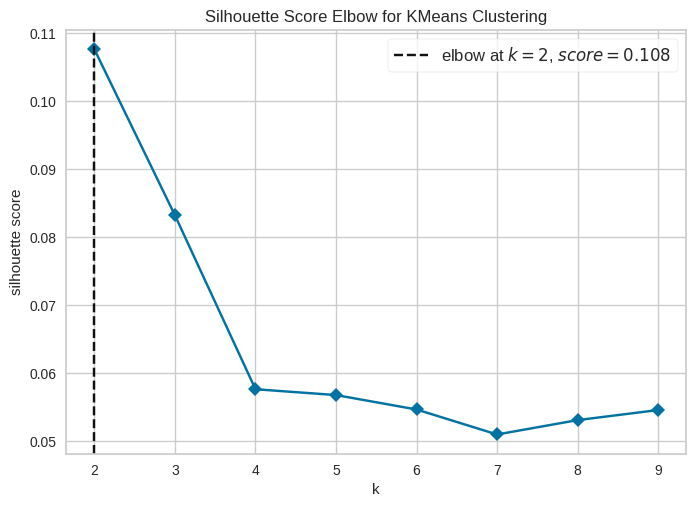

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [ ]:
#Elbow Method
from yellowbrick.cluster import KElbowVisualizer
model = KMeans(random_state=42)
visualizer = KElbowVisualizer( model, k=(2,10), metric='silhouette', timings=False )
visualizer.fit(train_df)
visualizer.show()

Diperoleh jumlah cluster optimal pada k = 2 dengan score sebesar 0.108. Hal ini menunjukkan bahwa data mahasiswa paling optimal dibagi menjadi dua kelompok utama berdasarkan pola pengeluaran dan kondisi finansialnya.

##Model Kmeans

In [ ]:
#Model Kmeans
kmeans = KMeans(
    n_clusters=2,
    random_state=42)
kmeans.fit(train_df)

KMeans(n_clusters=2, random_state=42)

In [ ]:
#Label Cluster
train_df['Cluster'] = kmeans.labels_
test_df['Cluster'] = kmeans.predict( test_df )
train_df['Cluster'].value_counts()

,count
Cluster,
1,519
0,260


Model K-Means berhasil membagi data mahasiswa ke dalam dua cluster utama.
- Cluster 1 memiliki jumlah anggota sebanyak 519 mahasiswa.
- Cluster 0 memiliki jumlah anggota sebanyak 260 mahasiswa.

Hasil clustering menunjukkan bahwa sebagian besar mahasiswa berada pada kelompok dengan karakteristik finansial dan pola pengeluaran yang relatif serupa. Perbedaan antar cluster menunjukkan adanya variasi perilaku pengelolaan keuangan mahasiswa dalam dataset.

##Evaluasi Silhouette Score

In [ ]:
#Silhouette Score
score = silhouette_score( train_df.drop('Cluster', axis=1), train_df['Cluster'] )
print("Silhouette Score:", score)

Silhouette Score: 0.10761640576059446


Hasil evaluasi menggunakan Silhouette Score memperoleh nilai sebesar 0,108. Nilai ini menunjukkan bahwa pemisahan antar cluster masih tergolong lemah karena karakteristik finansial dan pola pengeluaran mahasiswa cenderung cukup mirip.

Meskipun demikian, hasil clustering tetap dapat digunakan untuk melihat kecenderungan umum perilaku pengeluaran mahasiswa serta membedakan kelompok mahasiswa berdasarkan pola finansial yang dimiliki.

##Visualisasi Cluster dengan PCA


In [ ]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(
    train_df.drop('Cluster', axis=1))
pca_df = pd.DataFrame(
    pca_result,
    columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = train_df['Cluster']

pca_df.head()


,PCA1,PCA2,Cluster
0,-2.966162,-0.271075,0.0
1,-0.424885,-0.967330,1.0
2,-0.407951,-0.880263,0.0
3,-0.371276,-1.210509,NaN
4,-4.118675,-0.900090,1.0


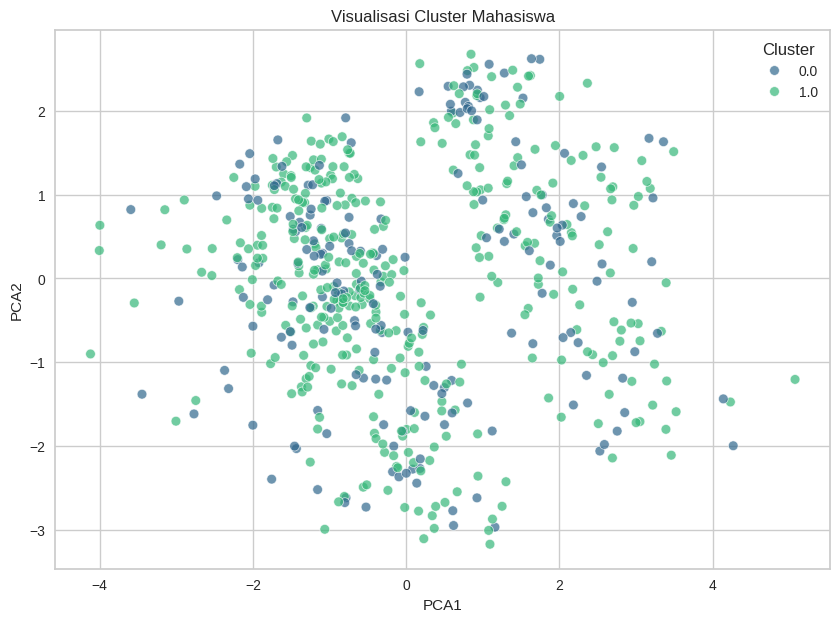

In [ ]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=pca_df,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='viridis',
    alpha=0.7)
plt.title('Visualisasi Cluster Mahasiswa')
plt.show()

Principal Component Analysis (PCA) digunakan untuk mereduksi dimensi data sehingga hasil clustering dapat divisualisasikan ke dalam dua dimensi utama, yaitu PCA1 dan PCA2. Visualisasi ini membantu dalam melihat pola persebaran data mahasiswa berdasarkan cluster yang terbentuk.

Berdasarkan hasil visualisasi PCA, terlihat bahwa persebaran antar cluster masih cukup berdekatan dan beberapa titik data menunjukkan overlap (saling bercampur) antar cluster. Hal ini menunjukkan bahwa karakteristik pengeluaran mahasiswa antar cluster masih relatif mirip. Kondisi tersebut sejalan dengan nilai silhouette score yang relatif rendah, sehingga pemisahan antar cluster belum terlalu optimal.

Selain itu, terdapat beberapa data dengan nilai NaN pada kolom cluster yang menunjukkan adanya data yang tidak terklasifikasi pada proses clustering. Namun, secara umum hasil visualisasi tetap dapat memberikan gambaran mengenai pola pengelompokan data mahasiswa berdasarkan karakteristik pengeluarannya.

##Analisis Karakteristik Cluster

In [ ]:
cluster_summary = train_df.groupby('Cluster').mean().round(2)

cluster_summary

,age,gender,year_in_school,major,monthly_income,financial_aid,tuition,housing,food,transportation,books_supplies,entertainment,personal_care,technology,health_wellness,miscellaneous,preferred_payment_method,total_spending,saving_ratio,spending_level
Cluster,,,,,,,,,,,,,,,,,,,,
0,0.13,0.03,-0.06,-0.08,0.01,0.02,0.04,0.8,0.42,0.26,0.32,0.17,0.13,0.33,0.2,0.27,0.01,1.11,-0.41,-1.22
1,-0.06,-0.02,0.03,0.04,-0.00,-0.01,-0.02,-0.4,-0.21,-0.13,-0.16,-0.08,-0.06,-0.16,-0.1,-0.14,-0.00,-0.56,0.21,0.61


In [ ]:
cluster_summary = train_df.groupby('Cluster').mean().round(2)
cluster_summary
train_df.groupby('Cluster')[[
    'monthly_income',
    'total_spending',
    'saving_ratio',
    'housing',
    'food',
    'entertainment',
    'technology'
]].mean().round(2)

,monthly_income,total_spending,saving_ratio,housing,food,entertainment,technology
Cluster,,,,,,,
0,0.01,1.11,-0.41,0.8,0.42,0.17,0.33
1,-0.00,-0.56,0.21,-0.4,-0.21,-0.08,-0.16


Berdasarkan nilai rata-rata terstandarisasi pada masing-masing variabel, diperoleh karakteristik yang berbeda pada setiap cluster mahasiswa.

**Cluster 0 : Mahasiswa dengan Pengeluaran Tinggi**

Cluster 0 memiliki nilai total_spending yang lebih tinggi dibandingkan Cluster 1. Pengeluaran pada kategori housing, food, transportation, books_supplies, technology, dan health_wellness juga cenderung lebih besar. Selain itu, nilai saving_ratio pada cluster ini bernilai negatif lebih besar, yang menunjukkan bahwa mahasiswa pada kelompok ini memiliki kecenderungan menggunakan sebagian besar pendapatannya untuk kebutuhan dan konsumsi sehari-hari.

Meskipun nilai monthly_income antar cluster relatif tidak jauh berbeda, mahasiswa pada Cluster 0 menunjukkan tingkat pengeluaran yang lebih tinggi. Hal ini diperkuat dengan nilai spending_level yang lebih tinggi dibanding cluster lainnya. Dengan demikian, Cluster 0 dapat dikategorikan sebagai kelompok mahasiswa dengan pola pengeluaran tinggi dan cenderung lebih konsumtif.

**Cluster 1 : Mahasiswa dengan Pengeluaran Lebih Stabil**

Cluster 1 memiliki nilai total_spending yang lebih rendah dibandingkan Cluster 0. Pengeluaran pada berbagai kategori seperti housing, food, entertainment, dan technology juga relatif lebih kecil. Selain itu, nilai saving_ratio pada cluster ini lebih baik dibandingkan Cluster 0, yang menunjukkan bahwa mahasiswa pada kelompok ini cenderung lebih mampu mengontrol pengeluaran dan memiliki pola keuangan yang lebih stabil.

Nilai spending_level pada Cluster 1 juga lebih rendah dibandingkan Cluster 0, sehingga cluster ini dapat dikategorikan sebagai kelompok mahasiswa dengan tingkat konsumsi yang lebih terkendali dan pengelolaan keuangan yang relatif lebih baik.

#**Persiapan Deployment Model**

##Pemisahan Data Training dan Testing

In [ ]:
#Memisahkan feature dan label cluster
X_train = train_df.drop('Cluster', axis=1)
y_train = train_df['Cluster']

X_test = test_df.drop('Cluster', axis=1)
y_test = test_df['Cluster']

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (779, 20)
X_test : (191, 20)
y_train: (779,)
y_test : (191,)


##Penyimpanan Dataset

In [ ]:
# Simpan dataset training dan testing

X_train.to_csv(
    'X_train.csv',
    index=False)

X_test.to_csv(
    'X_test.csv',
    index=False)

y_train.to_csv(
    'y_train.csv',
    index=False)

y_test.to_csv(
    'y_test.csv',
    index=False)

print("Data X dan y berhasil disimpan")

Data X dan y berhasil disimpan


##Penyimpanan Model dan Preprocessing

In [ ]:
# Simpan model clustering
joblib.dump(
    kmeans,
    'model_clustering.pkl')

# Simpan scaler
joblib.dump(
    scaler,
    'scaler.pkl')

# Simpan label encoder
joblib.dump(
    encoders,
    'label_encoders.pkl')

print("Model, scaler, dan label encoder berhasil disimpan")

Model, scaler, dan label encoder berhasil disimpan


Dataset berhasil dipisahkan menjadi data fitur (X) dan target cluster (y). Sebanyak 779 data digunakan untuk training dan 191 data digunakan untuk testing guna mendukung proses pengembangan dan evaluasi model lebih lanjut.

Model clustering, scaler, dan label encoder berhasil disimpan sebagai persiapan deployment dan integrasi ke dalam sistem FinTrack berbasis web.

#**Kesimpulan**

1. Hubungan Monthly Income dan Total Spending Mahasiswa

Hasil analisis menunjukkan bahwa hubungan antara monthly_income dan total_spending mahasiswa cenderung tidak terlalu kuat. Scatterplot memperlihatkan bahwa mahasiswa dengan pemasukan yang lebih tinggi tidak selalu memiliki pengeluaran yang lebih besar karena pola pengeluaran setiap mahasiswa cukup beragam.

Meskipun demikian, variabel monthly_income memiliki korelasi positif yang sangat kuat terhadap saving_ratio sebesar 0.88. Hal ini menunjukkan bahwa semakin tinggi pemasukan mahasiswa, maka kemampuan menyisihkan uang juga cenderung meningkat. Namun, sebagian besar mahasiswa masih memiliki saving_ratio bernilai negatif, yang menunjukkan bahwa pengeluaran mereka cenderung lebih besar dibandingkan pemasukan bulanan yang dimiliki.

2. Kategori Pengeluaran dengan Rata-Rata Tertinggi

Kategori pengeluaran terbesar mahasiswa berada pada housing, kemudian diikuti oleh food, technology, dan books_supplies. Hasil korelasi juga menunjukkan bahwa housing memiliki hubungan paling kuat terhadap total_spending sebesar 0.70.

Hal ini menunjukkan bahwa kebutuhan tempat tinggal, konsumsi sehari-hari, kebutuhan teknologi, dan kebutuhan akademik menjadi komponen utama dalam pengeluaran mahasiswa. Sebagian besar mahasiswa juga memiliki total pengeluaran pada tingkat menengah dengan distribusi yang relatif stabil setelah proses preprocessing dilakukan.

3. Pola Pengeluaran Berdasarkan Metode Pembayaran

Hasil visualisasi menunjukkan bahwa metode pembayaran yang paling banyak digunakan mahasiswa adalah mobile payment app, diikuti credit/debit card dan cash. Kondisi ini menunjukkan bahwa mahasiswa cenderung lebih terbiasa menggunakan transaksi digital dibandingkan pembayaran tunai.

Berdasarkan boxplot, median pengeluaran antar metode pembayaran terlihat relatif mirip. Namun, pengguna credit/debit card dan mobile payment app memiliki variasi pengeluaran yang sedikit lebih besar dibandingkan pengguna cash. Hal ini menunjukkan bahwa penggunaan metode pembayaran digital cenderung berkaitan dengan pola pengeluaran yang lebih fleksibel dan bervariasi.

4. Pengelompokan Mahasiswa Berdasarkan Pola Pengeluaran dan Kondisi Finansial

Hasil clustering menggunakan metode K-Means membagi mahasiswa ke dalam dua kelompok utama berdasarkan pola pengeluaran dan kondisi finansialnya.

* **Cluster 0** merupakan kelompok mahasiswa dengan tingkat pengeluaran lebih tinggi. Kelompok ini memiliki nilai total_spending yang lebih besar pada berbagai kategori seperti housing, food, technology, dan transportation. Selain itu, nilai saving_ratio pada cluster ini juga lebih negatif sehingga menunjukkan kecenderungan pengeluaran yang lebih konsumtif.

* **Cluster 1** merupakan kelompok mahasiswa dengan pola pengeluaran yang lebih stabil dan terkendali. Mahasiswa pada cluster ini memiliki total_spending yang lebih rendah serta saving_ratio yang lebih baik dibandingkan Cluster 0.

Visualisasi PCA menunjukkan bahwa persebaran antar cluster masih cukup berdekatan dan beberapa data saling overlap. Hal ini menunjukkan bahwa karakteristik pengeluaran antar mahasiswa masih relatif mirip, sehingga pemisahan cluster belum sepenuhnya optimal. Namun demikian, clustering tetap mampu memberikan gambaran umum mengenai segmentasi pola pengeluaran mahasiswa berdasarkan kondisi finansial mereka.


#**Rekomendasi**
1. Monitoring Pengeluaran Utama

Mahasiswa disarankan untuk lebih memperhatikan pengeluaran pada kategori housing dan food karena kedua kategori tersebut memberikan kontribusi terbesar terhadap total pengeluaran. Pemantauan pengeluaran secara rutin dapat membantu mengurangi pengeluaran yang tidak diperlukan dan menjaga kestabilan kondisi keuangan.

2. Pengelolaan Pemasukan dan Pengeluaran

Sebagian besar mahasiswa memiliki saving_ratio bernilai negatif, sehingga diperlukan pengelolaan keuangan yang lebih baik agar pengeluaran tidak melebihi pemasukan bulanan. Penyusunan anggaran bulanan dan pembatasan pengeluaran pada kebutuhan non-prioritas dapat membantu meningkatkan kemampuan menabung.

3. Pemanfaatan Visualisasi Keuangan

Visualisasi data pengeluaran dan pemasukan dapat digunakan untuk membantu memahami pola keuangan secara lebih jelas dan terstruktur. Dengan melihat tren pengeluaran tiap kategori, mahasiswa dapat lebih mudah mengevaluasi kebiasaan finansial dan menentukan prioritas pengeluaran.

4. Pengendalian Penggunaan Pembayaran Digital

Penggunaan metode pembayaran digital seperti mobile payment app dan credit/debit card perlu disertai dengan kontrol pengeluaran yang baik. Kemudahan transaksi digital dapat meningkatkan frekuensi pengeluaran apabila tidak disertai pengawasan terhadap penggunaan dana.

5. Pemanfaatan Analisis Pola Pengeluaran

Hasil clustering menunjukkan adanya perbedaan pola pengeluaran antar mahasiswa. Oleh karena itu, analisis pola pengeluaran dapat dimanfaatkan untuk membantu mahasiswa mengenali kondisi finansial mereka serta menentukan strategi pengelolaan keuangan yang lebih sesuai dengan kebiasaan pengeluaran masing-masing.